# ISLR Chapter One: Statistical Learning

When creating a model, there can be up to two types of variable, the input and output variables. The input variables, also known as predictors, independent variables, or features, while the output variables can be known as response or dependent variable. With a quantitative response Y to X predictors, with irreducible error term $\epsilon$ (mean zero random error term), the following model shows the relationship. Broadly, statistical learning is the estimation of the function $f$.

$Y = f(X) + \epsilon$

Estimation can be for prediction or inference. For prediction we try and fit the best model to reduce the reducible error, while being stuck with the irreducible error. We can then predict outputs for given inputs, while not being interested in how the function behaves. With inference it is the opposite, we are interested in the working of the function rather than the output. It is desired to know how predictors influence the response.

The goal of estimating the unknown function $f$ is the purpose of modelling, using a training data set to arrive at an estimation of $f$, through either parametric or non-parametric methods. For parametric we chose a model based on assumptions of the nature of $f$, then use the training data to fit the model. As we choose the model, it is only the parameters of the model we need to estimate, hence parametric. It is possible the model may not be a good fit to estimate $f$, but more flexible models may over-fit, where the model follows the noise of the data rather than the underlying function. Non-parametric models make no assumptions about the model shape, and so can fit better than parametric methods, however they need much more data for training. Supervised learning is where there is a corresponding response variable for the predictors, un-supervised is where there is no response variable. Variables, both predictors and response, can be either quantitative or qualitative, the former being numeric in nature, the latter categorical. Quantitative problems tend to be called regression problems, qualitative classification problems.

Once a model has been created it is necessary to evaluate it. In regression the Mean Squared Error (MSE) can be used, which sums the square of the difference between the actual predictor value and its predicted value and takes the average. This can be computed for the training data, and then for the test data, to check the model performance. Scoring low in training data but high in test data may mean the model is over-fitted; it has fitted to the noise in the training data rather than the underlying function. A rule states that the more flexible the model, the more over-fitting is possible. This is a problem, known as the bias-variance trade-off, where the model bias is the error introduced by a model not suited to estimate the shape of $f$, while variance is the flexibility to over-fit, the variance that would occur if different training sets were used.

$MSE = \frac{1}{n}\sum_{i=1}^{n} (y_{i} - \hat{f}(x_{i}))^{2}$


In [ ]:
import numpy as np
from matplotlib.pyplot import subplots
import pandas as pd

## Question Eight

In [ ]:
college = pd.read_csv('/home/ogladr-kjarr/repos/online-learning-notes/books/ISLR-Python/data/College.csv',
                        index_col=0)
college

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Worcester State College,No,2197,1515,543,4,26,3089,2029,6797,3900,500,1200,60,60,21.0,14,4469,40
Xavier University,Yes,1959,1805,695,24,47,2849,1107,11520,4960,600,1250,73,75,13.3,31,9189,83
Xavier University of Louisiana,Yes,2097,1915,695,34,61,2793,166,6900,4200,617,781,67,75,14.4,20,8323,49
Yale University,Yes,10705,2453,1317,95,99,5217,83,19840,6510,630,2115,96,96,5.8,49,40386,99


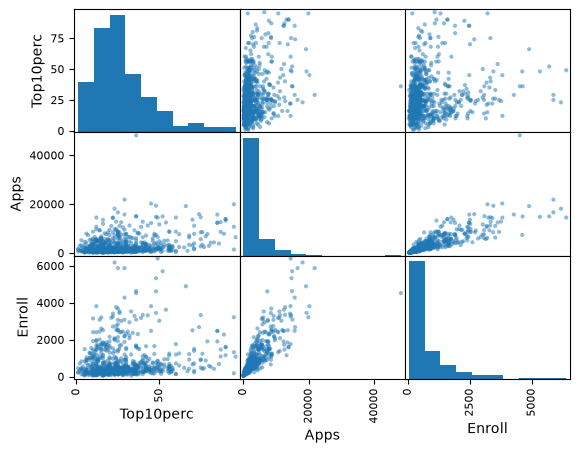

In [51]:
pd.plotting.scatter_matrix(college.loc[:, ["Top10perc", "Apps", "Enroll"]]);

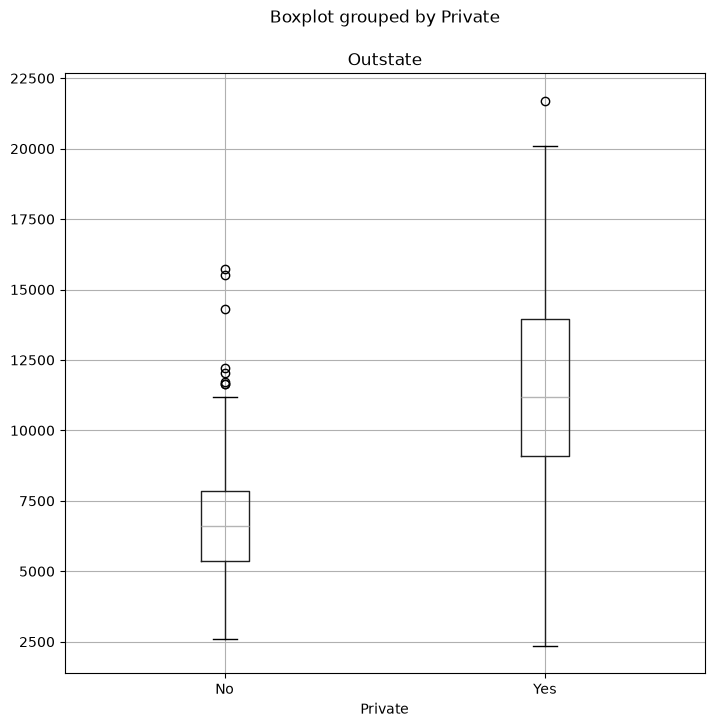

In [54]:
fig , ax = subplots(figsize =(8, 8))
college.boxplot('Outstate', by='Private', ax=ax);

In [61]:
college['Elite'] = pd.cut(college['Top10perc'],
[0,50,100],
labels =['No', 'Yes'])

college['Elite'].value_counts()

Elite
No     699
Yes     78
Name: count, dtype: int64

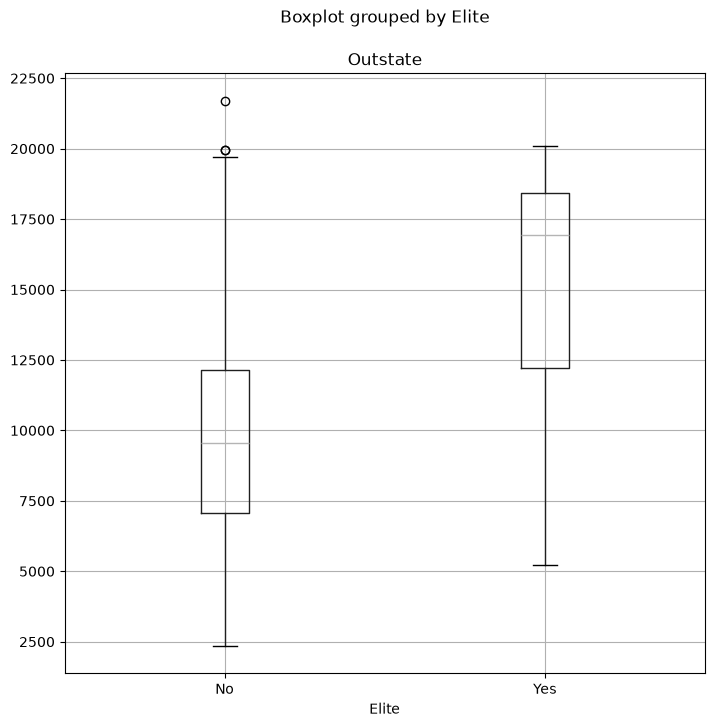

In [62]:
fig , ax = subplots(figsize =(8, 8))
college.boxplot('Outstate', by='Elite', ax=ax);

In [ ]:
ax = df.plot.hist(column=["age"], by="gender", figsize=(10, 8))

fig, axs = plt.subplots(2, 2,tight_layout=True)

# We can set the number of bins with the *bins* keyword argument.
axs[0].hist(dist1, bins=n_bins)
axs[1].hist(dist2, bins=n_bins)

plt.show()

<Axes: ylabel='Frequency'>

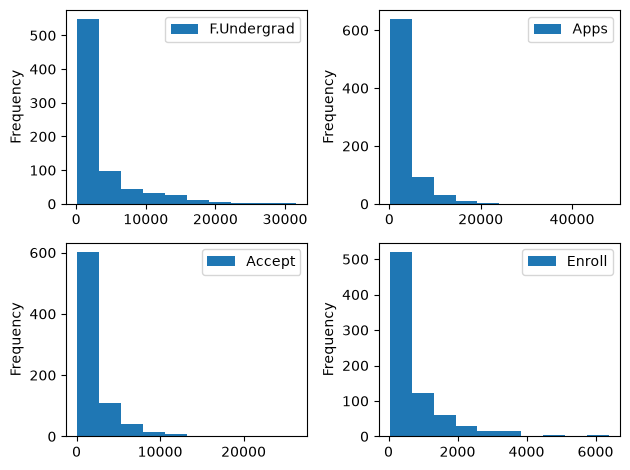

In [66]:
fig, axs = subplots(2, 2, tight_layout=True)

college.plot.hist(column="F.Undergrad", ax=axs[0,0])
college.plot.hist(column="Apps", ax=axs[0,1])
college.plot.hist(column="Accept", ax=axs[1,0])
college.plot.hist(column="Enroll", ax=axs[1,1])

## Question Nine

In [95]:
auto = pd.read_csv('/home/ogladr-kjarr/repos/online-learning-notes/books/ISLR-Python/data/Auto.csv',
                        na_values=["?"])
auto.shape

(397, 9)

In [96]:
auto = auto.dropna()
auto.shape

(392, 9)

In [97]:
auto.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592,1.576531
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737,0.805518
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000,1.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


In [99]:
auto.drop(auto.index[10:85]).describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
count,317.000000,317.000000,317.000000,317.000000,317.000000,317.000000,317.000000,317.000000
mean,24.374763,5.381703,187.880126,101.003155,2938.854890,15.704101,77.123028,1.599369
std,7.872565,1.658135,100.169973,36.003208,811.640668,2.719913,3.127158,0.819308
min,11.000000,3.000000,68.000000,46.000000,1649.000000,8.500000,70.000000,1.000000
25%,18.000000,4.000000,101.000000,75.000000,2215.000000,14.000000,75.000000,1.000000
50%,23.900000,4.000000,146.000000,90.000000,2795.000000,15.500000,77.000000,1.000000
75%,30.500000,6.000000,250.000000,115.000000,3520.000000,17.300000,80.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,4997.000000,24.800000,82.000000,3.000000
